# FX Implied Vol Surface — end-to-end walkthrough

Quotes → conventions → **market-strangle calibration** → smile → surface → arbitrage check → 3D plot.

All data here is the illustrative EURUSD sample (calm regime, not live). Vols/rates in the files are in **percent**; everything in code is decimals.

In [1]:
from pathlib import Path

import numpy as np

from fxvol import (
    OptionType,
    VolSurface,
    calibrate_wing,
    check_surface,
    implied_quotes_from_smile,
    load_csv,
)
from fxvol.io_report import calibration_report

market = load_csv(Path("eurusd_quotes.csv"))
market.pair, market.spot, [q.tenor for q in market.quotes]

('EURUSD', 1.085, ['1W', '1M', '3M', '6M', '1Y'])

## 1. Conventions

Every quoted delta is meaningless until we fix the convention. EURUSD (registry default): **unadjusted** deltas (premium paid in USD, the quote ccy), **spot** delta up to 1Y / forward beyond, **delta-neutral-straddle** ATM.

In [2]:
conv = market.conventions
for p in market.pillars():
    dc = conv.delta_convention(p.expiry)
    print(f"{p.tenor:>3}  T={p.expiry:.4f}  F={p.forward:.6f}  {dc.describe()}")

 1W  T=0.0192  F=1.085375  spot delta, unadjusted
 1M  T=0.0822  F=1.086606  spot delta, unadjusted
 3M  T=0.2521  F=1.089934  spot delta, unadjusted
 6M  T=0.5014  F=1.094836  spot delta, unadjusted
 1Y  T=1.0000  F=1.104707  spot delta, unadjusted


## 2. The market-strangle step (the part most implementations get wrong)

The quoted butterfly is a **market strangle**: `sigma_ms = atm + bf` is a single vol; its ±25Δ strikes and the resulting *strangle price* `v_ms` are the actual observable. We then solve for smile wing vols `(sigma_c, sigma_p)` such that `sigma_c − sigma_p = RR` **and** the smile strangle reprices `v_ms`. The smile butterfly `0.5(sigma_c+sigma_p) − atm` ends up *different* from the quoted bf:

In [3]:
pillar = market.pillars()[-1]          # 1Y, biggest |RR|
q = pillar.quote
dc = conv.delta_convention(pillar.expiry)
w = calibrate_wing(pillar, dc, q.atm_vol, q.rr_25, q.bf_25, 0.25)
print(f"market strangle vol  : {w.sigma_ms:.4%}  price v_ms = {w.market_strangle_price:.8f}")
print(f"smile wing vols      : call {w.sigma_call:.4%} @K={w.strike_call:.6f}, put {w.sigma_put:.4%} @K={w.strike_put:.6f}")
print(f"quoted bf = {w.bf:.4%}   vs   smile-strangle bf = {w.smile_bf:.4%}   (they differ because RR != 0)")
print(f"strangle reprice error: {w.reprice_error:.2e}")

market strangle vol  : 9.1800%  price v_ms = 0.03000835
smile wing vols      : call 8.9343% @K=1.175936, put 9.3843% @K=1.043462
quoted bf = 0.2800%   vs   smile-strangle bf = 0.2593%   (they differ because RR != 0)
strangle reprice error: 1.08e-16


## 3. Build the full surface and prove the round-trip

`VolSurface.from_market` runs the calibration at every pillar (25Δ and 10Δ wings) and assembles PCHIP total-variance smiles. The acceptance test: **implying the quotes back out of the surface must reproduce the inputs**.

In [4]:
surface = VolSurface.from_market(market)
print(f"{'tenor':>5} {'ATM err':>10} {'RR25 err':>10} {'BF25 err':>10} {'RR10 err':>10} {'BF10 err':>10}  (vol points)")
for p in surface.pillars:
    qq = p.calibration.pillar.quote
    imp = implied_quotes_from_smile(p.smile, p.calibration.pillar, market.conventions)
    print(f"{p.tenor:>5} {abs(imp.atm_vol-qq.atm_vol)*100:10.2e} {abs(imp.rr_25-qq.rr_25)*100:10.2e} "
          f"{abs(imp.bf_25-qq.bf_25)*100:10.2e} {abs(imp.rr_10-qq.rr_10)*100:10.2e} {abs(imp.bf_10-qq.bf_10)*100:10.2e}")

tenor    ATM err   RR25 err   BF25 err   RR10 err   BF10 err  (vol points)
   1W   0.00e+00   1.55e-12   6.09e-13   3.44e-12   7.40e-12
   1M   0.00e+00   9.42e-14   8.67e-16   3.67e-12   4.97e-12
   3M   0.00e+00   7.34e-13   4.87e-13   5.25e-12   5.76e-12
   6M   0.00e+00   1.05e-12   1.10e-12   9.64e-12   1.22e-11
   1Y   0.00e+00   2.83e-12   1.57e-12   2.67e-12   3.72e-12


## 4. Query API: vol / price / Greeks at any strike, delta, tenor

In [5]:
t = 0.5
f = surface.forward(t)
k25, v25 = surface.vol_from_delta(0.25, t, OptionType.CALL)
g = surface.greeks(k25, t, OptionType.CALL)
print(f"F(0.5y) = {f:.6f}, ATMF vol = {surface.vol(f, t):.4%}")
print(f"25d call: K = {k25:.6f}, vol = {v25:.4%}")
print(f"greeks: delta_spot={g.delta_spot:.4f}  vega={g.vega:.6f}  vanna={g.vanna:.4f}  volga={g.volga:.4f}")
strikes = np.linspace(1.00, 1.20, 9)
np.round(np.asarray(surface.vol(strikes, t)) * 100, 4)   # vectorised

F(0.5y) = 1.094809, ATMF vol = 8.5005%
25d call: K = 1.141861, vol = 8.5636%
greeks: delta_spot=0.2500  vega=0.242368  vanna=2.6752  volga=1.3641


array([9.8201, 9.3257, 8.9375, 8.6317, 8.4996, 8.527 , 8.5985, 8.8454,
       9.1775])

## 5. Static no-arbitrage checks

Convexity of undiscounted C(K) (density ≥ 0), the Durrleman `g(k) ≥ 0` condition on total variance, and calendar monotonicity of `w(k,T)`. Diagnostics only — quotes are never silently altered.

In [6]:
report = check_surface(surface)
print(report.summary())

Arbitrage check: PASS
  butterfly violations: 0; calendar violations: 0


## 6. Pictures

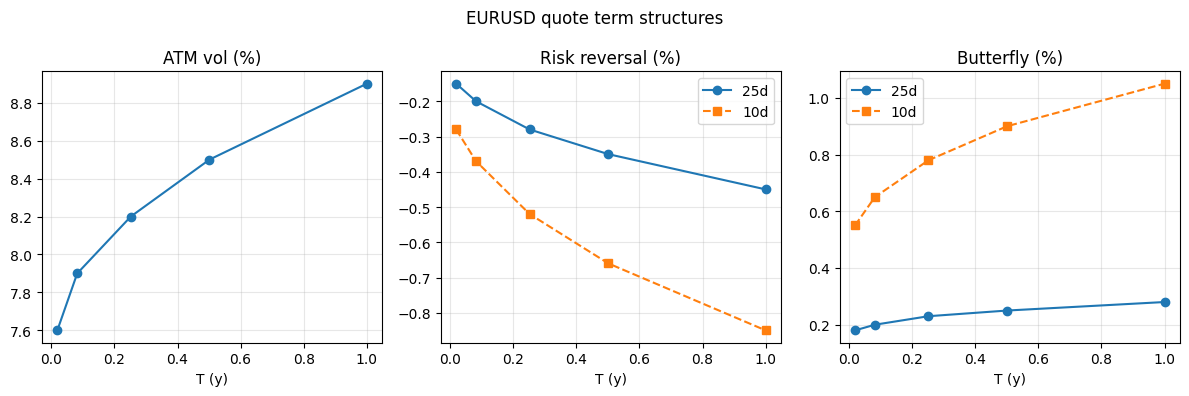

In [7]:
from fxvol.viz import (
    plot_arbitrage,
    plot_density,
    plot_smiles,
    plot_surface_3d,
    plot_term_structure,
)

plot_term_structure(market);

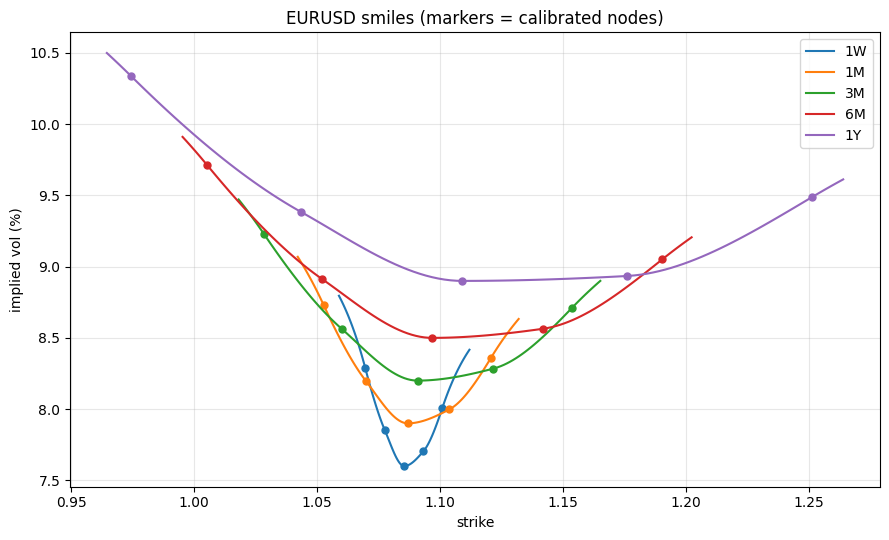

In [8]:
plot_smiles(surface);

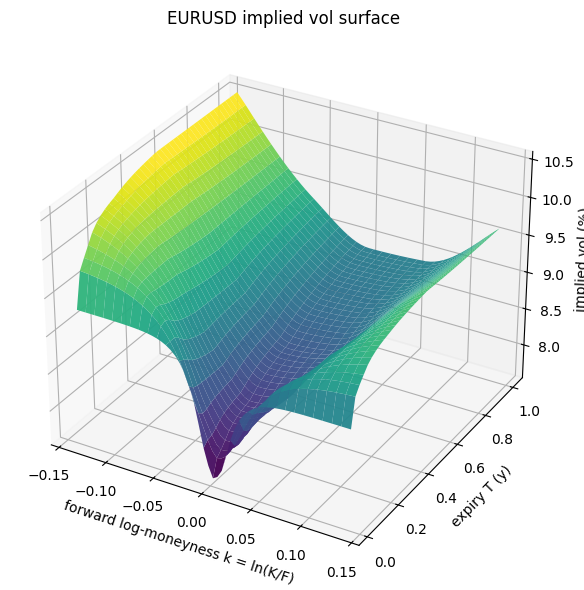

In [9]:
plot_surface_3d(surface);

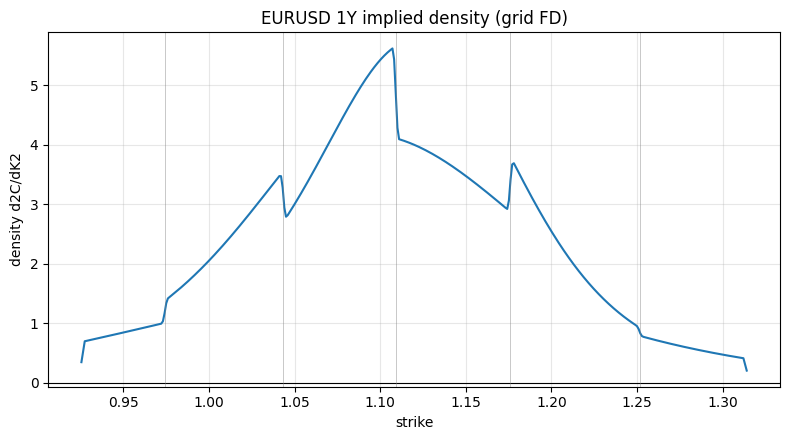

In [10]:
plot_density(surface, "1Y");

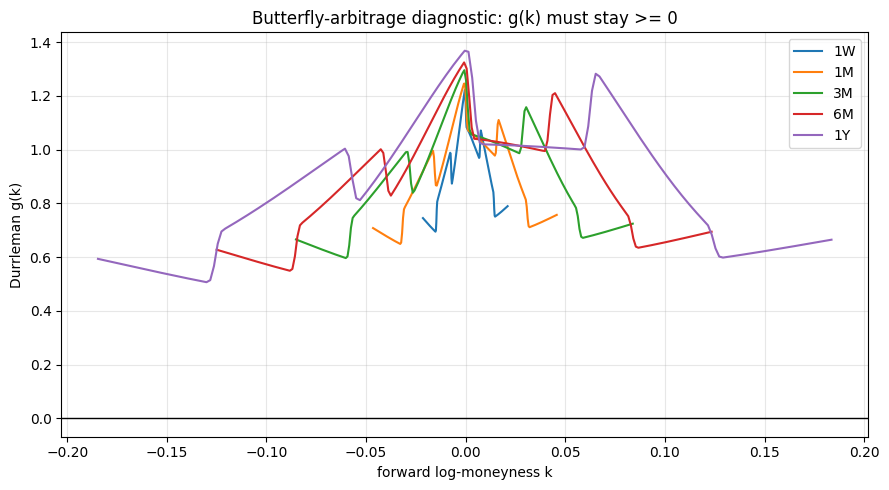

In [11]:
plot_arbitrage(report);

## 7. Full text report

In [12]:
print(calibration_report(market, surface, report))

FX vol surface calibration report -- EURUSD
valuation date : 2026-06-30   spot: 1.085
conventions    : premium-adjusted=False, atm=dns, spot-delta cutoff=1.0y, day count=act/365f

  1W  T=0.019178  F=1.085375  df_dom=0.999176  delta conv: spot delta, unadjusted
      ATM strike 1.085435  vol 7.600%
      25% wing: sigma_ms=7.780%  v_ms=0.00348783
        smile: call 7.704% @K=1.093271  put 7.854% @K=1.077509  smile-bf=0.179% (quoted bf=0.180%)  reprice err=1.11e-16
      10% wing: sigma_ms=8.150%  v_ms=0.00115965
        smile: call 8.009% @K=1.100976  put 8.289% @K=1.069599  smile-bf=0.549% (quoted bf=0.550%)  reprice err=-1.25e-16

  1M  T=0.082192  F=1.086606  df_dom=0.996472  delta conv: spot delta, unadjusted
      ATM strike 1.086885  vol 7.900%
      25% wing: sigma_ms=8.100%  v_ms=0.00752195
        smile: call 7.998% @K=1.103791  put 8.198% @K=1.069854  smile-bf=0.198% (quoted bf=0.200%)  reprice err=-5.55e-17
      10% wing: sigma_ms=8.550%  v_ms=0.00251953
        smile: cal